<a href="https://colab.research.google.com/github/annatsamoyra-prog/homework/blob/main/PREDICT_THE_NR_OF_UPVOTES_A_POST_WILL_GET.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import sklearn
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import seaborn as sns

# special matplotlib argument for improved plots
from matplotlib import rcParams
sns.set_style("whitegrid")
sns.set_context("poster")

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

In [3]:
df = pd.read_csv('/content/train_NIR5Yl1.csv (1).zip')

In [5]:
print(df.head())

       ID Tag  Reputation  Answers  Username    Views  Upvotes
0   52664   a      3942.0      2.0    155623   7855.0     42.0
1  327662   a     26046.0     12.0     21781  55801.0   1175.0
2  468453   c      1358.0      4.0     56177   8067.0     60.0
3   96996   a       264.0      3.0    168793  27064.0      9.0
4  131465   c      4271.0      4.0    112223  13986.0     83.0


In [6]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 330045 entries, 0 to 330044
Data columns (total 7 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   ID          330045 non-null  int64  
 1   Tag         330045 non-null  object 
 2   Reputation  330045 non-null  float64
 3   Answers     330045 non-null  float64
 4   Username    330045 non-null  int64  
 5   Views       330045 non-null  float64
 6   Upvotes     330045 non-null  float64
dtypes: float64(4), int64(2), object(1)
memory usage: 17.6+ MB
None


In [7]:
print(df.describe())


                  ID    Reputation        Answers       Username  \
count  330045.000000  3.300450e+05  330045.000000  330045.000000   
mean   235748.682789  7.773147e+03       3.917672   81442.888803   
std    136039.418471  2.706141e+04       3.579515   49215.100730   
min         1.000000  0.000000e+00       0.000000       0.000000   
25%    117909.000000  2.820000e+02       2.000000   39808.000000   
50%    235699.000000  1.236000e+03       3.000000   79010.000000   
75%    353620.000000  5.118000e+03       5.000000  122559.000000   
max    471493.000000  1.042428e+06      76.000000  175738.000000   

              Views        Upvotes  
count  3.300450e+05  330045.000000  
mean   2.964507e+04     337.505358  
std    8.095646e+04    3592.441135  
min    9.000000e+00       0.000000  
25%    2.594000e+03       8.000000  
50%    8.954000e+03      28.000000  
75%    2.687000e+04     107.000000  
max    5.231058e+06  615278.000000  


In [8]:
df.keys()

Index(['ID', 'Tag', 'Reputation', 'Answers', 'Username', 'Views', 'Upvotes'], dtype='object')

In [9]:
# έλεγχος για κενές τιμές
print(df.isnull().sum())


ID            0
Tag           0
Reputation    0
Answers       0
Username      0
Views         0
Upvotes       0
dtype: int64


In [11]:
df = df.dropna()


In [12]:
df = pd.get_dummies(df, columns=['Tag'], drop_first=True)


In [13]:
X = df.drop("Upvotes", axis=1)
y = df["Upvotes"]

In [16]:
from sklearn.model_selection import train_test_split


In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [26]:
y_pred = model.predict(X_test)

In [22]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(rmse)

3455.192019119621


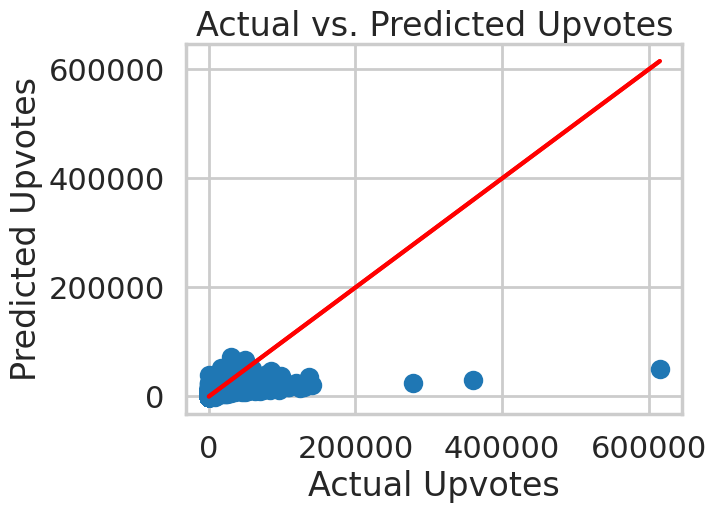

In [31]:
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Upvotes')
plt.ylabel('Predicted Upvotes')
plt.title('Actual vs. Predicted Upvotes')

# Calculate max value for setting the diagonal line range dynamically
max_val = max(y_test.max(), y_pred.max())

plt.plot([0, max_val], [0, max_val], color = 'red')

plt.plot([0, max_val], [0, max_val], color = 'red')

/tmp/ipykernel_639/2890453809.py:8: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig('upvotes_prediction.png', dpi=150, bbox_inches='tight') # Σώζει την εικόνα


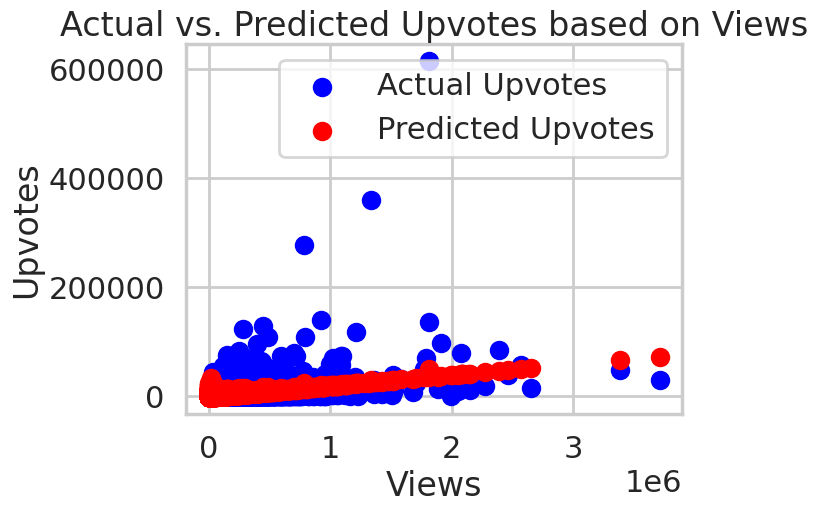

In [29]:
s1 = plt.scatter(X_test['Views'], y_test, color='b', marker='o', label='Actual Upvotes') # Plot data
plt.xlabel('Views')
plt.ylabel('Upvotes')
plt.title('Actual vs. Predicted Upvotes based on Views')

plt.scatter(X_test['Views'], y_pred, color='red', label='Predicted Upvotes') # οπτικοποιεί την πρόβλεψη
plt.legend()
plt.savefig('upvotes_prediction.png', dpi=150, bbox_inches='tight') # Σώζει την εικόνα
plt.show()